In [1]:
!pip install librosa soundfile scikit-learn seaborn joblib -q

In [2]:
import os
import glob
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os
import glob
import warnings
warnings.filterwarnings("ignore")

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Flatten,
    Dense
)
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [6]:
!wget -q -O ravdess.zip \
https://www.kaggle.com/api/v1/datasets/download/uwrfkaggler/ravdess-emotional-speech-audio

!unzip -q ravdess.zip -d ravdess_data

In [7]:
for root, dirs, files in os.walk("/content/ravdess_data"):
    if files:
        print("Folder:", root)
        print("Number of files:", len(files))
        print()

Folder: /content/ravdess_data/Actor_15
Number of files: 60

Folder: /content/ravdess_data/Actor_08
Number of files: 60

Folder: /content/ravdess_data/Actor_07
Number of files: 60

Folder: /content/ravdess_data/audio_speech_actors_01-24/Actor_15
Number of files: 60

Folder: /content/ravdess_data/audio_speech_actors_01-24/Actor_08
Number of files: 60

Folder: /content/ravdess_data/audio_speech_actors_01-24/Actor_07
Number of files: 60

Folder: /content/ravdess_data/audio_speech_actors_01-24/Actor_04
Number of files: 60

Folder: /content/ravdess_data/audio_speech_actors_01-24/Actor_21
Number of files: 60

Folder: /content/ravdess_data/audio_speech_actors_01-24/Actor_18
Number of files: 60

Folder: /content/ravdess_data/audio_speech_actors_01-24/Actor_14
Number of files: 60

Folder: /content/ravdess_data/audio_speech_actors_01-24/Actor_05
Number of files: 60

Folder: /content/ravdess_data/audio_speech_actors_01-24/Actor_02
Number of files: 60

Folder: /content/ravdess_data/audio_speech_act

In [8]:
audio_files = glob.glob(
    "/content/ravdess_data/**/*.wav",
    recursive=True
)

print("Total audio files:", len(audio_files))

Total audio files: 2880


In [9]:
import pandas as pd

emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

data = []

for file in audio_files:
    filename = os.path.basename(file)

    parts = filename.split("-")

    if len(parts) >= 3:
        emotion_code = parts[2]

        if emotion_code in emotion_map:
            emotion = emotion_map[emotion_code]

            data.append({
                "file": file,
                "emotion": emotion
            })

df = pd.DataFrame(data)

print(df.head())
print("\nTotal samples:", len(df))

                                                file    emotion
0  /content/ravdess_data/Actor_15/03-01-02-01-02-...       calm
1  /content/ravdess_data/Actor_15/03-01-08-01-02-...  surprised
2  /content/ravdess_data/Actor_15/03-01-08-02-01-...  surprised
3  /content/ravdess_data/Actor_15/03-01-02-02-02-...       calm
4  /content/ravdess_data/Actor_15/03-01-04-02-02-...        sad

Total samples: 2880


In [10]:
print(df["emotion"].value_counts())

emotion
calm         384
surprised    384
sad          384
angry        384
fearful      384
disgust      384
happy        384
neutral      192
Name: count, dtype: int64


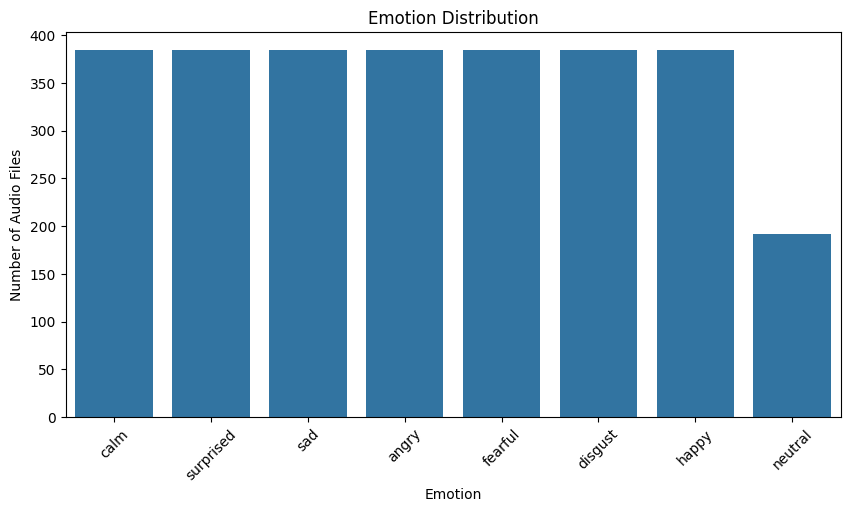

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="emotion",
    order=df["emotion"].value_counts().index
)

plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Audio Files")
plt.xticks(rotation=45)

plt.show()

In [12]:
from IPython.display import Audio, display

sample_file = df.iloc[0]["file"]

print("Emotion:", df.iloc[0]["emotion"])
print("File:", sample_file)

display(Audio(sample_file))

Emotion: calm
File: /content/ravdess_data/Actor_15/03-01-02-01-02-02-15.wav


In [13]:
import librosa

file_path = df.iloc[0]["file"]

audio, sample_rate = librosa.load(
    file_path,
    sr=22050
)

print("Audio shape:", audio.shape)
print("Sample rate:", sample_rate)
print("Duration:", len(audio) / sample_rate, "seconds")

Audio shape: (78724,)
Sample rate: 22050
Duration: 3.570249433106576 seconds


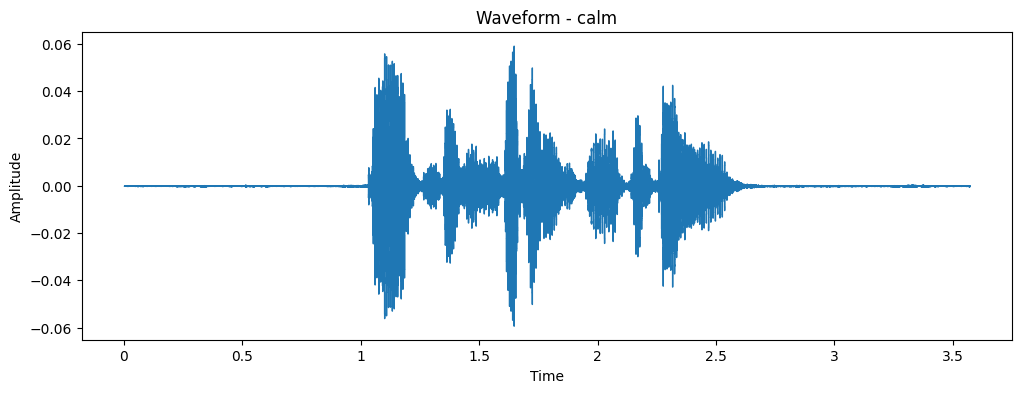

In [14]:
plt.figure(figsize=(12, 4))

librosa.display.waveshow(
    audio,
    sr=sample_rate
)

plt.title(
    f"Waveform - {df.iloc[0]['emotion']}"
)

plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()

In [15]:
def extract_mfcc(file_path, n_mfcc=40, max_pad_len=250):

    try:
        audio, sample_rate = librosa.load(
            file_path,
            sr=22050
        )

        mfcc = librosa.feature.mfcc(
            y=audio,
            sr=sample_rate,
            n_mfcc=n_mfcc
        )

        # Pad or truncate MFCCs to a fixed length
        if mfcc.shape[1] < max_pad_len:
            pad_width = max_pad_len - mfcc.shape[1]
            mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfcc = mfcc[:, :max_pad_len]

        mfcc = mfcc.T

        return mfcc

    except Exception as e:
        print("Error:", file_path, e)
        return None

In [16]:
import numpy as np
mfcc_features = extract_mfcc(
    df.iloc[0]["file"]
)

print("MFCC shape:", mfcc_features.shape)

MFCC shape: (250, 40)


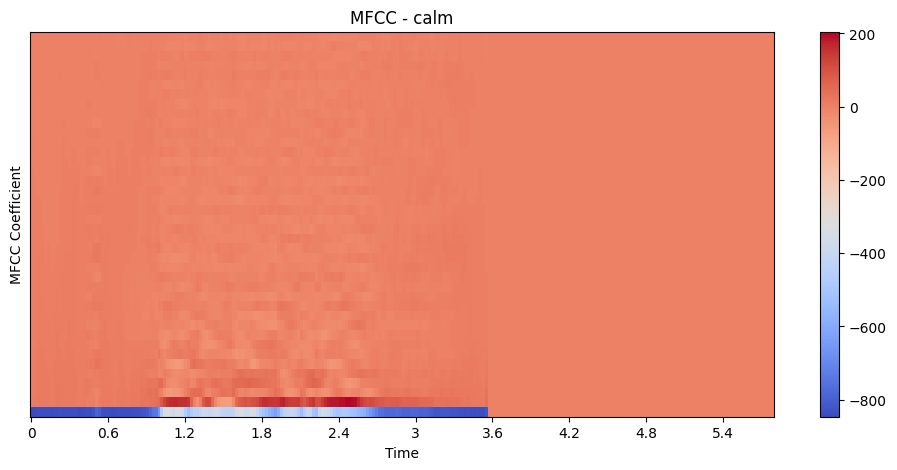

In [17]:
plt.figure(figsize=(12, 5))

librosa.display.specshow(
    mfcc_features.T,
    x_axis="time"
)

plt.colorbar()

plt.title(
    f"MFCC - {df.iloc[0]['emotion']}"
)

plt.xlabel("Time")
plt.ylabel("MFCC Coefficient")

plt.show()

In [18]:
import numpy as np

X = []
y = []

for index, row in df.iterrows():

    features = extract_mfcc(
        row["file"]
    )

    if features is not None:
        X.append(features)
        y.append(row["emotion"])

X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)
print("Label shape:", y.shape)

Feature shape: (2880, 250, 40)
Label shape: (2880,)


In [19]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes:")
print(label_encoder.classes_)

Classes:
['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [20]:
for emotion, encoded in zip(
    label_encoder.classes_,
    range(len(label_encoder.classes_))
):
    print(emotion, "=", encoded)

angry = 0
calm = 1
disgust = 2
fearful = 3
happy = 4
neutral = 5
sad = 6
surprised = 7


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 2304
Testing samples: 576


In [22]:
mean = X_train.mean()
std = X_train.std()

X_train = (X_train - mean) / (std + 1e-8)
X_test = (X_test - mean) / (std + 1e-8)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (2304, 250, 40)
Testing shape: (576, 250, 40)


In [23]:
MAX_LEN = 250
N_MFCC = 40

num_classes = len(label_encoder.classes_)

model = Sequential([

    Conv1D(
        64,
        kernel_size=3,
        activation="relu",
        input_shape=(MAX_LEN, N_MFCC)
    ),

    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(
        128,
        kernel_size=3,
        activation="relu"
    ),

    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(
        256,
        kernel_size=3,
        activation="relu"
    ),

    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.4),

    Dense(
        num_classes,
        activation="softmax"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 248, 64)        │         7,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 248, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 124, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 124, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 122, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 122, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 61, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 61, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 59, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 59, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 29, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 29, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7424)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       950,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,084,232 (4.14 MB)

 Trainable params: 1,083,336 (4.13 MB)

 Non-trainable params: 896 (3.50 KB)

In [24]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [25]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [26]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=10,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 129ms/step - accuracy: 0.2241 - loss: 2.2321 - val_accuracy: 0.1670 - val_loss: 2.0890
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 109ms/step - accuracy: 0.3201 - loss: 1.7535 - val_accuracy: 0.2473 - val_loss: 2.3990
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.3738 - loss: 1.6460 - val_accuracy: 0.2560 - val_loss: 2.3650
Epoch 4/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 132ms/step - accuracy: 0.4102 - loss: 1.5435 - val_accuracy: 0.1540 - val_loss: 3.8515
Epoch 5/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy: 0.4482 - loss: 1.4880 - val_accuracy: 0.2451 - val_loss: 2.9921
Epoch 6/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - accuracy: 0.4607 - loss: 1.3959 - val_accuracy: 0.3362 - val_loss: 2.2047


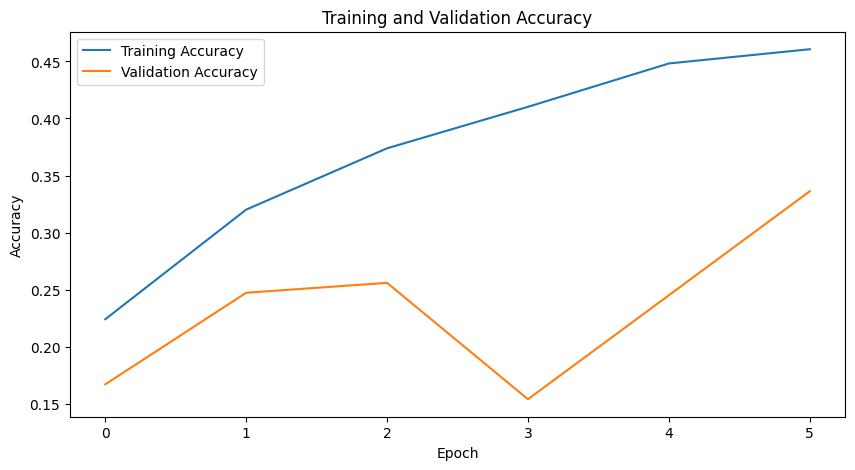

In [27]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

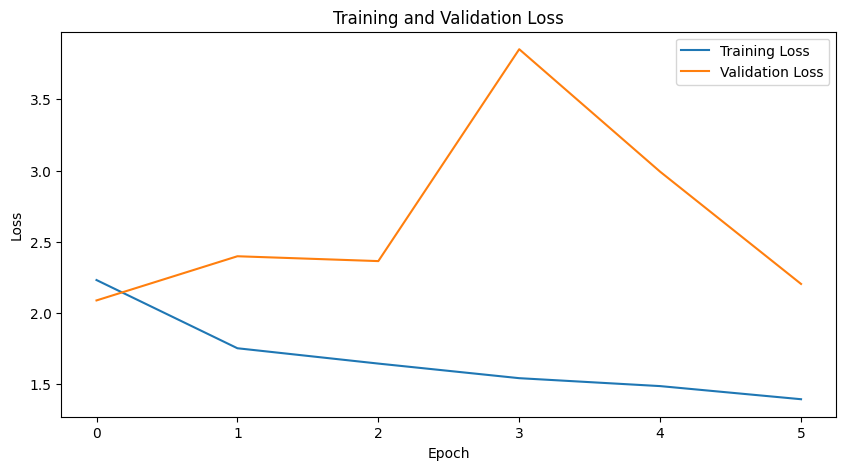

In [28]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [29]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 2.071225166320801
Test Accuracy: 0.1770833283662796


In [30]:
y_probability = model.predict(
    X_test
)

y_pred = np.argmax(
    y_probability,
    axis=1
)

print("Predictions generated.")

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
Predictions generated.


In [31]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

       angry       0.00      0.00      0.00        76
        calm       0.30      0.86      0.44        77
     disgust       0.00      0.00      0.00        77
     fearful       0.00      0.00      0.00        77
       happy       0.20      0.06      0.10        77
     neutral       0.00      0.00      0.00        38
         sad       0.09      0.40      0.15        77
   surprised       0.00      0.00      0.00        77

    accuracy                           0.18       576
   macro avg       0.07      0.17      0.09       576
weighted avg       0.08      0.18      0.09       576



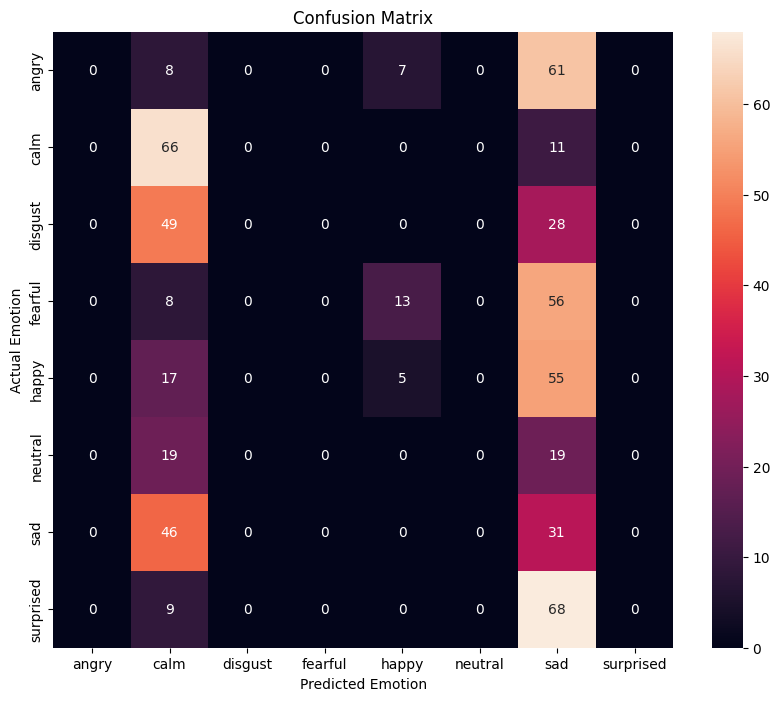

In [32]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")

plt.show()

In [33]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Test Accuracy: {accuracy:.4f}"
)

Test Accuracy: 0.1771


In [34]:
def predict_emotion(file_path):

    features = extract_mfcc(
        file_path
    )

    if features is None:
        return "Could not process audio."

    features = np.expand_dims(
        features,
        axis=0
    )

    features = (
        features - mean
    ) / (std + 1e-8)

    probabilities = model.predict(
        features,
        verbose=0
    )[0]

    predicted_index = np.argmax(
        probabilities
    )

    predicted_emotion = (
        label_encoder
        .inverse_transform(
            [predicted_index]
        )[0]
    )

    confidence = (
        probabilities[predicted_index]
        * 100
    )

    return predicted_emotion, confidence

In [35]:
test_file = df.iloc[10]["file"]

emotion, confidence = predict_emotion(
    test_file
)

print("Predicted Emotion:", emotion)
print(f"Confidence: {confidence:.2f}%")

Predicted Emotion: sad
Confidence: 18.05%


In [36]:
from IPython.display import Audio, display

test_file = df.iloc[10]["file"]

print("Actual Emotion:", df.iloc[10]["emotion"])

display(
    Audio(test_file)
)

emotion, confidence = predict_emotion(
    test_file
)

print("Predicted Emotion:", emotion)
print(f"Confidence: {confidence:.2f}%")

Actual Emotion: angry


Predicted Emotion: sad
Confidence: 18.05%


In [37]:
from google.colab import files

uploaded = files.upload()

Saving record_out.wav to record_out.wav


In [38]:
uploaded_file = list(uploaded.keys())[0]

emotion, confidence = predict_emotion(
    uploaded_file
)

print("Predicted Emotion:", emotion)
print(f"Confidence: {confidence:.2f}%")

Predicted Emotion: sad
Confidence: 40.80%


In [39]:
display(
    Audio(uploaded_file)
)

In [40]:
model.save(
    "emotion_recognition_cnn.keras"
)

print("Model saved successfully.")

Model saved successfully.


In [42]:
import joblib
import numpy as np

joblib.dump(
    label_encoder,
    "label_encoder.pkl"
)

np.save(
    "mfcc_mean.npy",
    mean
)

np.save(
    "mfcc_std.npy",
    std
)

print("Supporting files saved.")

Supporting files saved.


In [44]:
from google.colab import files

files.download(
    "emotion_recognition_cnn.keras"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [47]:
files.download("label_encoder.pkl")
files.download("mfcc_mean.npy")
files.download("mfcc_std.npy")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>